In [1]:
import numpy as np
import pandas as pd
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

In [2]:
power_df = pd.read_csv('/Users/sam/Desktop/StationLevelPowerForecasting/data/power_df_2008-2406.csv')

In [3]:
power_df

,Unnamed: 0,recordTimestamp,siteId,activeStationIds,totalPower,numberOfActiveSessions,fractionOfRegularSessions,averageRegularPricePerHour,averageScheduledPricePerHour,power1,...,dcosId4,dcosId5,dcosId6,dcosId7,dcosId8,isArtificialData,dayNumber,isWeekend,weekNumber,isHoliday
0,0,2020-08-18 18:30:00-07:00,25.0,[],0.0,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,False,1,False,34,False
1,1,2020-08-18 18:35:00-07:00,25.0,[],0.0,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,False,1,False,34,False
2,2,2020-08-18 18:40:00-07:00,25.0,[],0.0,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,False,1,False,34,False
3,3,2020-08-18 18:45:00-07:00,25.0,[],0.0,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,False,1,False,34,False
4,4,2020-08-18 18:50:00-07:00,25.0,[],0.0,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,False,1,False,34,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
400994,400994,2024-06-11 02:25:00-07:00,25.0,[],0.0,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,False,1,False,24,False
400995,400995,2024-06-11 02:30:00-07:00,25.0,[],0.0,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,False,1,False,24,False
400996,400996,2024-06-11 02:35:00-07:00,25.0,[],0.0,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,False,1,False,24,False
400997,400997,2024-06-11 02:40:00-07:00,25.0,[],0.0,0.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,True,1,False,24,False


In [4]:
power_df['year'] = pd.to_datetime(power_df['recordTimestamp'], utc=True).dt.year
power_df['month'] = pd.to_datetime(power_df['recordTimestamp'], utc=True).dt.month
power_df['totalPower'].fillna(0, inplace=True)
power_df['totalPower'] = power_df['totalPower'] / 1000

# Historical Running Monthly Peak Power

In [5]:
grouped = power_df.groupby(['year', 'month'])[['recordTimestamp', 'totalPower']].agg(list).reset_index()

In [6]:
len(grouped.loc[3]['totalPower'])

8640

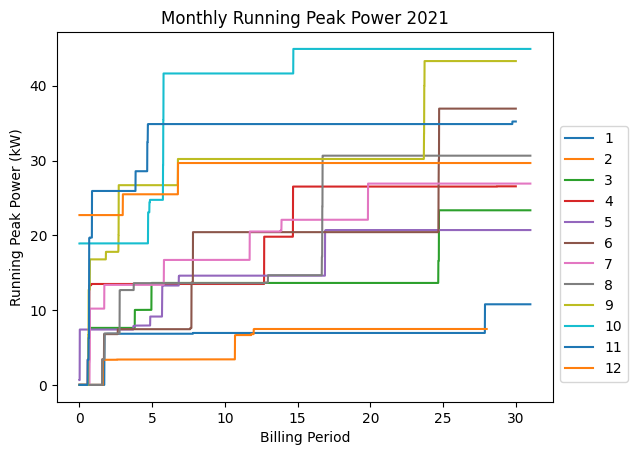

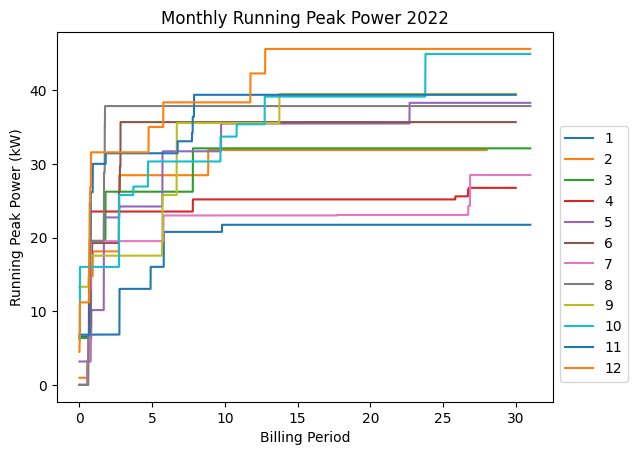

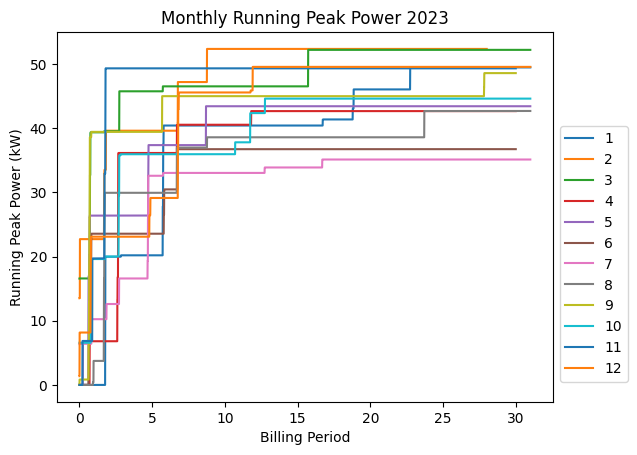

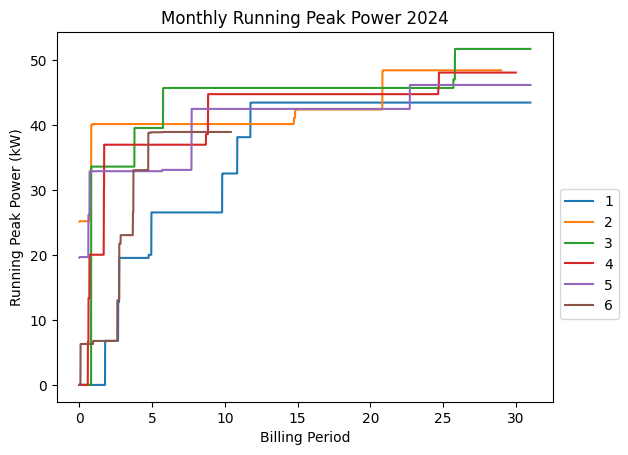

In [7]:
for year in [2021, 2022, 2023, 2024]:
    for index, row in grouped[grouped['year'] == year].iterrows():
        power = row['totalPower']
        running_peak_power = np.maximum.accumulate(power)
        plt.plot(np.arange(len(running_peak_power)) / 288, running_peak_power, label=row['month'])
    
    plt.legend(bbox_to_anchor=(1, 0.4), loc='center left')
    plt.xlabel('Billing Period')
    plt.ylabel('Running Peak Power (kW)')
    plt.title(f"Monthly Running Peak Power {year}")
    plt.show()

In [8]:
maxes = power_df.groupby(['year', 'month'])['totalPower'].max()
maxes = maxes.iloc[3:]

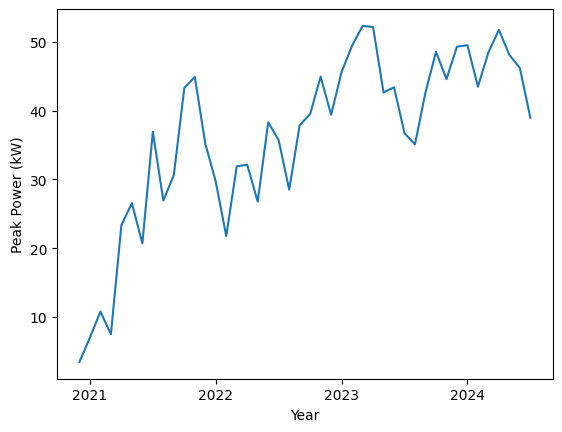

In [9]:
plt.plot(np.arange(2020 + 11/12, 2024 + 7/12, 1/12), maxes)
plt.xticks(np.arange(2021, 2025))
plt.ylabel("Peak Power (kW)")
plt.xlabel('Year');

# Looking at associations between various variables and demand charge

In [10]:
df = pd.read_csv('/Users/sam/Desktop/StationLevelPowerForecasting/data/Sessions3.csv')
df['year'] = pd.to_datetime(df['connectTime']).dt.year
df['month'] = pd.to_datetime(df['connectTime']).dt.month

r = -0.2983761969426301


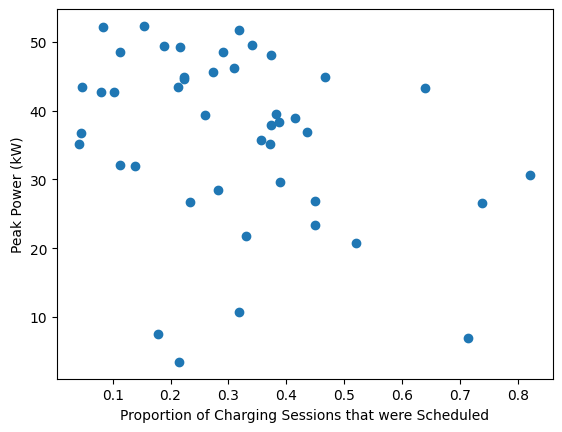

In [11]:
df['year'] = df['connectTime'].astype('datetime64[s]').dt.year
df['month'] = df['connectTime'].astype('datetime64[s]').dt.month


plt.scatter(df.groupby(['year', 'month'])['scheduled'].mean(), maxes)
plt.xlabel('Proportion of Charging Sessions that were Scheduled')
plt.ylabel("Peak Power (kW)");

print(f"r = {pearsonr(df.groupby(['year', 'month'])['scheduled'].mean(), maxes)[0]}")

r = 0.8804415505115613


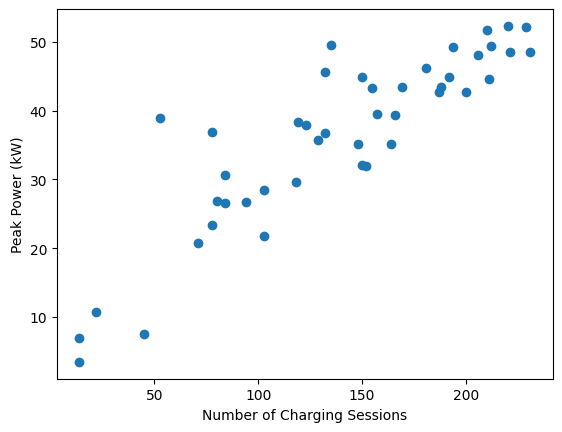

In [12]:
plt.scatter(df.groupby(['year', 'month'])['scheduled'].count(), maxes)
plt.xlabel('Number of Charging Sessions')
plt.ylabel("Peak Power (kW)")

print(f"r = {pearsonr(df.groupby(['year', 'month'])['scheduled'].count(), maxes)[0]}");

r = 0.6902501051378163


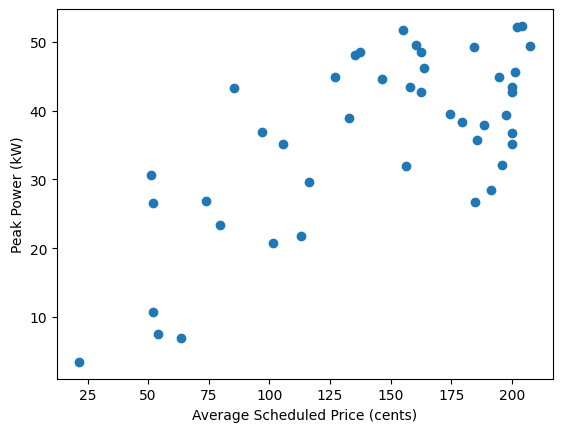

In [13]:
plt.scatter(df.groupby(['year', 'month'])['sch_centsPerHr'].mean(), maxes)
plt.xlabel('Average Scheduled Price (cents)')
plt.ylabel("Peak Power (kW)")

print(f"r = {pearsonr(df.groupby(['year', 'month'])['sch_centsPerHr'].mean(), maxes)[0]}");

r = 0.7153204328903396


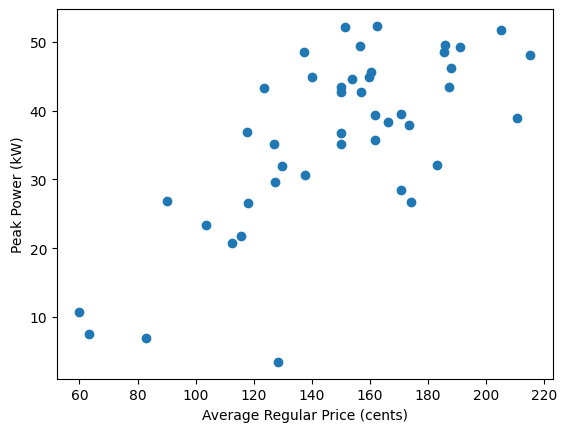

In [14]:
plt.scatter(df.groupby(['year', 'month'])['reg_centsPerHr'].mean(), maxes)
plt.xlabel('Average Regular Price (cents)')
plt.ylabel("Peak Power (kW)")

print(f"r = {pearsonr(df.groupby(['year', 'month'])['reg_centsPerHr'].mean(), maxes)[0]}");

r = -0.2842284845211929


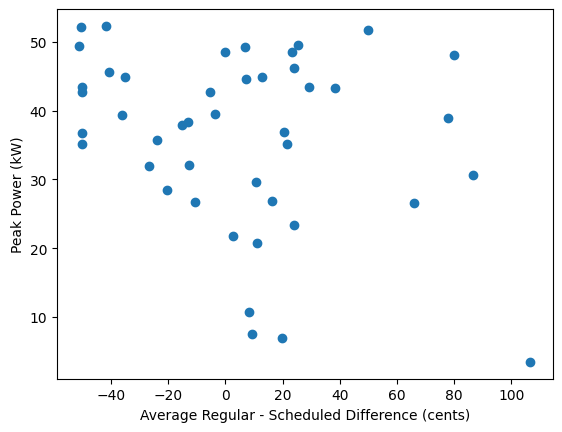

In [15]:
df['reg-sched'] = df['reg_centsPerHr'] - df['sch_centsPerHr']

plt.scatter(df.groupby(['year', 'month'])['reg-sched'].mean(), maxes)
plt.xlabel('Average Regular - Scheduled Difference (cents)')
plt.ylabel("Peak Power (kW)")

print(f"r = {pearsonr(df.groupby(['year', 'month'])['reg-sched'].mean(), maxes)[0]}");

# Building a Linear Regression Model to Predict Demand Charge

In [16]:
np.random.seed(42)

df['date'] = df['connectTime'].astype('datetime64[s]').dt.date
df['date'] = pd.to_datetime(df['date'])

# Step 1: Convert the column to a timezone-aware datetime in UTC
power_df['date'] = pd.to_datetime(power_df['recordTimestamp'], utc=True)
power_df['date'] = power_df['date'].dt.tz_convert('America/Los_Angeles')
power_df['date'] = power_df['date'].dt.tz_localize(None)

# Get the minimum and maximum dates in your DataFrame
min_date = df['date'].min()
max_date = df['date'].max() - pd.Timedelta(days=30)  # Exclude the last 30 days

# Generate 200 random starting points for the 30-day segments
random_start_dates = pd.to_datetime(np.random.choice(pd.date_range(min_date, max_date), size=1000, replace=False))

# Initialize an empty list to store the selected segments
selected_segments = []

x = []
y = []
full_power_segments = []

# Loop through each random starting date
for start_date in random_start_dates:
    # Select the 30-day segment based on the random starting date
    end_date = start_date + pd.Timedelta(days=30)
    segment = df[(df['date'] >= start_date) & (df['date'] < end_date)]
    power_segment = power_df[(power_df['date'] >= start_date) & (power_df['date'] < end_date)]

    # Randomly choose a day to split the segment into two halves
    d = np.random.randint(1, 30)
    split_date = end_date - pd.Timedelta(days=d)  # Random day between start_date and end_date
    
    # Split the segment into two halves
    first_half = segment[segment['date'] < split_date]
    second_half = segment[segment['date'] >= split_date]

    first_half_power = power_segment[power_segment['date'] < split_date]
    second_half_power = power_segment[power_segment['date'] >= split_date]
    
    # Calculate average for the first half
    max_so_far = first_half_power['totalPower'].max()
    prop_scheduled = first_half['scheduled'].mean()
    reg_cents_per_hour = first_half['reg_centsPerHr'].mean()
    sch_cents_per_hour = first_half['sch_centsPerHr'].mean()
    num_reg = len(first_half[first_half['regular'] == 1])
    num_sch = len(first_half[first_half['scheduled'] == 1])

    if not np.isnan([max_so_far, prop_scheduled, reg_cents_per_hour, sch_cents_per_hour, num_reg, num_sch, num_sch + num_reg, d]).any():
        x.append([max_so_far, prop_scheduled, reg_cents_per_hour, sch_cents_per_hour, num_reg, num_sch, num_sch + num_reg, d])        
        y.append(max(power_segment['totalPower']) - max(first_half_power['totalPower']))  # Calculate row-wise max
        full_power_segments.append([first_half_power['totalPower'], second_half_power['totalPower']])

In [17]:
df_cleaned = pd.DataFrame(data=x, columns = ['running_max', 'prop_scheduled', 'reg_cents_per_hour', 'sch_cents_per_hour', 'num_reg', 'num_sch', 'num', 'd'])
X = df_cleaned[['prop_scheduled', 'reg_cents_per_hour', 'sch_cents_per_hour', 'd']]

In [18]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
power_train, power_test, _, _ = train_test_split(full_power_segments, np.zeros(len(full_power_segments)), test_size=0.2, random_state=42)
df_cleaned_train, df_cleaned_test, _, _ = train_test_split(df_cleaned, np.zeros(len(df_cleaned)), test_size=0.2, random_state=42)


# Creating a linear regression model
model = LinearRegression(fit_intercept=False)

# Training the model
model.fit(X_train, y_train)

# Making predictions
y_pred = df_cleaned_test['running_max'] + np.clip(model.predict(X_test), a_min=0, a_max=None)

mse = mean_squared_error(df_cleaned_test['running_max'] + y_test, y_pred)
print("Mean Squared Error:", mse)

Mean Squared Error: 34.82632095673864


In [19]:
print("Intercept:", model.intercept_)
print("Coefficient(s):", model.coef_)

Intercept: 0.0
Coefficient(s): [-0.50156551 -0.00718001 -0.00657856  0.4791757 ]


The below cell visualizes one prediction in the test set. 

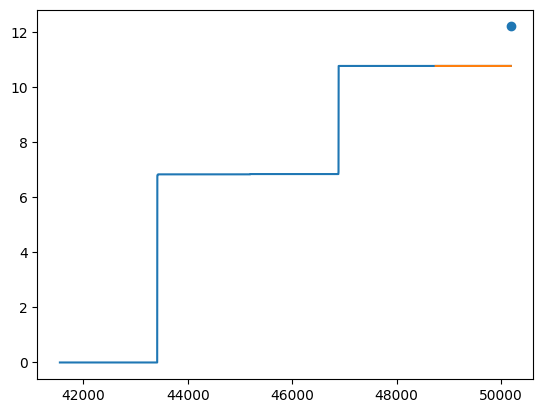

In [20]:
y_pred = np.clip(np.array(y_pred), a_min=0, a_max=None)

i = np.random.randint(0, len(y_pred))
plt.plot(pd.concat([power_test[i][0], power_test[i][1]]).cummax())
plt.plot(pd.concat([power_test[i][0], power_test[i][1]]).cummax().loc[power_test[i][1].index])
plt.scatter(max(power_test[i][1].index), y_pred[i]);